<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/03_3_loss_functions_and_optimizers_in_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loss Functions and Optimizers in Deep Learning
After setting up the network architecture, two key steps follow: evaluating the network's performance and fine-tuning its weights to enhance that performance. Loss functions are used to measure performance, while optimizers adjust the weights accordingly.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers, losses, utils
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 1. Regression - Mean Squared Error
Regression tasks involve predicting continuous numerical values. A common loss function used here is Mean Squared Error (MSE), which calculates the average of the squared differences between predicted values and actual targets. MSE penalizes larger errors more heavily, making it suitable when you want to reduce large deviations in predictions.

An alternative is Mean Absolute Error (MAE), which measures the average of absolute differences and is more robust to outliers.

Epoch 1/500


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.7784
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.5936
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.7593
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3.6025
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.6200 
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.5694
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.6337
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.6239
Epoch 9/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.5471
Epoch 10/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3.4664
Epoch 11/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3.5478
Epoch 12/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.4486 
Epoch 13/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.5172
Epoch 14/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.4112
Epoch 15/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.3508
Epoch 16/500
4/4 ━━━━━━━━━━━━

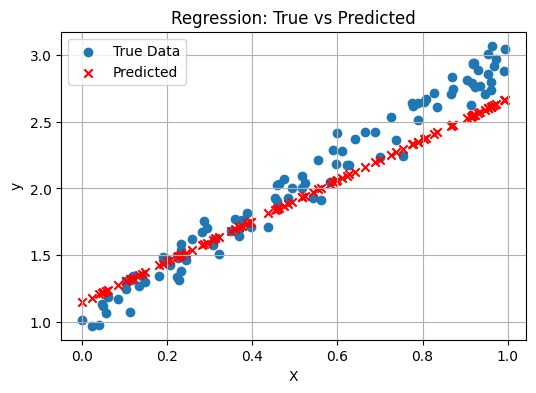

In [2]:
# Generate simple linear data: y = 2x + 1 + noise
X_reg = np.random.rand(100, 1)
y_reg = 2 * X_reg + 1 + 0.1 * np.random.randn(100, 1)

# Build model
model_reg = models.Sequential([
    layers.Dense(1, input_shape=(1,))
])

# Compile with MSE loss
model_reg.compile(optimizer='adam', loss='mean_squared_error')

# Train
model_reg.fit(X_reg, y_reg, epochs=500, verbose=1) # change verbose to 0 / 1 if you want to unsee / see training progress bar

# Predict
y_reg_pred = model_reg.predict(X_reg)

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(X_reg, y_reg, label='True Data')
plt.scatter(X_reg, y_reg_pred, label='Predicted', color='red', marker='x')
plt.title('Regression: True vs Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## 2. Binary Classification - Binary Cross-Entropy
Binary Classification problems involve predicting one of two possible outcomes (e.g., positive or negative). The typical loss function used is Binary Cross-Entropy (also called log loss). This loss measures the difference between the predicted probability and the actual label (0 or 1).

It works best when the model outputs a probability via a sigmoid activation function in the final layer. A lower binary cross-entropy indicates that the model's predicted probabilities are close to the true labels.

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5825 - loss: 0.6913 - val_accuracy: 0.6878 - val_loss: 0.6812
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7284 - loss: 0.6756 - val_accuracy: 0.7608 - val_loss: 0.6490
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7735 - loss: 0.6357 - val_accuracy: 0.7758 - val_loss: 0.5877
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7986 - loss: 0.5662 - val_accuracy: 0.7998 - val_loss: 0.5146
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8247 - loss: 0.4894 - val_accuracy: 0.8224 - val_loss: 0.4543
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8436 - loss: 0.4270 - val_accuracy: 0.8452 - val_loss: 0.4049
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8629 - loss: 0.3739 - val_accuracy: 0.8554 - val_loss: 0.3713
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8761 - loss: 0.3388 - val_accuracy: 0.8622 - val_loss: 0.

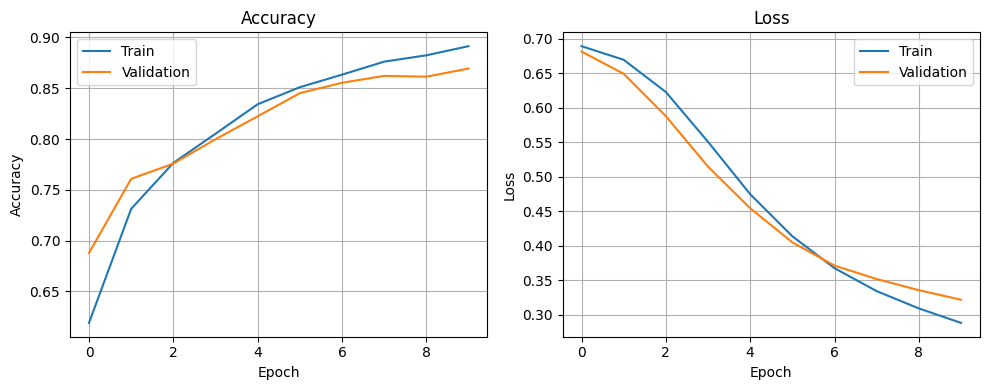

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# -------------------------------
# Load IMDB Sentiment Data
# -------------------------------
# Keep only the top 10,000 most frequent words
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

# Pad sequences to the same length
maxlen = 200
X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test, maxlen=maxlen)

# -------------------------------
# Build the Model
# -------------------------------
model = models.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=16, input_length=maxlen),  # word embeddings
    layers.GlobalAveragePooling1D(),  # average over time
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # output is probability of positive sentiment
])

# Compile with Binary Cross-Entropy loss
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# -------------------------------
# Train the Model with Progress Bar
# -------------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    verbose=1  # progress bar
)

# -------------------------------
# Evaluate on Test Set
# -------------------------------
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.2f}")

# -------------------------------
# Plot Accuracy and Loss
# -------------------------------
plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. Multi-class Classification - With Confusion Matrix
Multi-class Classification tasks involve assigning inputs to one of three or more distinct categories. The most commonly used loss function here is Categorical Cross-Entropy, which compares the predicted probability distribution over classes (from a softmax activation layer) to the true one-hot encoded labels.

For cases where labels are encoded as integers rather than one-hot vectors, Sparse Categorical Cross-Entropy can be used instead. Both functions guide the model to assign higher probabilities to the correct class.

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.2840 - loss: 1.1983 - val_accuracy: 0.3333 - val_loss: 0.9933
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3030 - loss: 1.2211 - val_accuracy: 0.3333 - val_loss: 0.9774
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3281 - loss: 1.1662 - val_accuracy: 0.3333 - val_loss: 0.9617
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3480 - loss: 1.1486 - val_accuracy: 0.4167 - val_loss: 0.9470
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3874 - loss: 1.1336 - val_accuracy: 0.5000 - val_loss: 0.9328
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4036 - loss: 1.1247 - val_accuracy: 0.5000 - val_loss: 0.9191
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4244 - loss: 1.0379 - val_accuracy: 0.5000 - val_loss: 0.9060
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4281 - loss: 1.0321 - val_accuracy: 0.5833 - val_loss: 0.8933
Epoch 9/50

<Figure size 600x600 with 0 Axes>

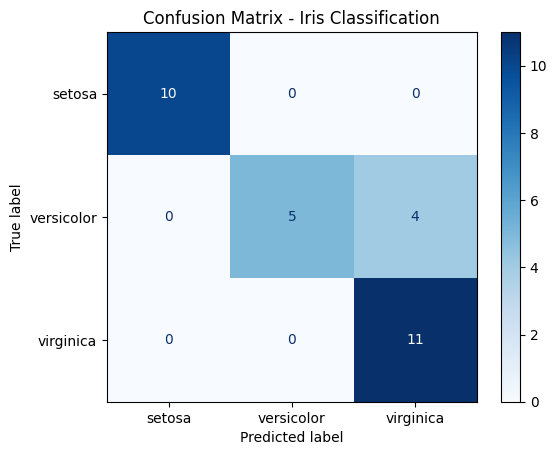

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, utils
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -------------------------------
# Load and Prepare the Iris Dataset
# -------------------------------
iris = load_iris()
X = iris.data
y = iris.target

# Standardize features (important for neural networks)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert labels to one-hot
y_one_hot = utils.to_categorical(y, num_classes=3)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# -------------------------------
# Build the Model
# -------------------------------
model = models.Sequential([
    layers.Dense(10, activation='relu', input_shape=(4,)),
    layers.Dense(3, activation='softmax')  # 3 classes: setosa, versicolor, virginica
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# -------------------------------
# Train with Progress Bar
# -------------------------------
history = model.fit(X_train, y_train, epochs=50, verbose=1, validation_split=0.1)

# -------------------------------
# Evaluate and Predict
# -------------------------------
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.2f}")

# Predict class labels
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix - Iris Classification')
plt.grid(False)
plt.show()